In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config_v6.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Mounted at /content/drive
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 30  |  Patience: 8
Use Focal   : False  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.6264     0.6931    0.6597    0.7690    0.7334    LR: 5.00e-04


2      0.5660     0.8064    0.7670    0.8145    0.7679    LR: 5.00e-04


3      0.5187     0.8628    0.8292    0.8297    0.7754    LR: 5.00e-04


4      0.4727     0.9159    0.8903    0.8275    0.7720    LR: 5.00e-04


...

7      0.3921     0.9802    0.9732    0.8233    0.7597    LR: 2.50e-04


8      0.3818     0.9882    0.9839    0.8285    0.7666    LR: 2.50e-04


9      0.3793     0.9891    0.9852    0.8035    0.7448    LR: 1.25e-04


10     0.3753     0.9911    0.9879    0.8235    0.7591    LR: 1.25e-04


11     0.3734     0.9929    0.9904    0.8227    0.7589    LR: 1.25e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.88      0.88      0.88      3030
      Sexist       0.63      0.64      0.63       970

    accuracy                           0.82      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.82      0.82      0.82      4000

Accuracy : 0.8227
Macro F1 : 0.7589
Weighted F1 : 0.8228

Confusion Matrix (raw):
[[2675  355]
 [ 354  616]]


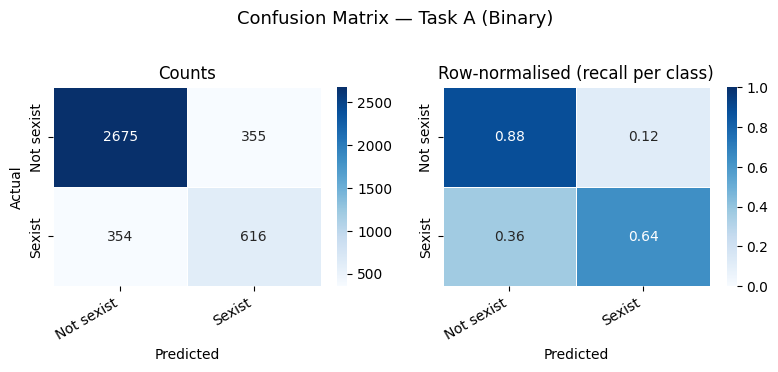

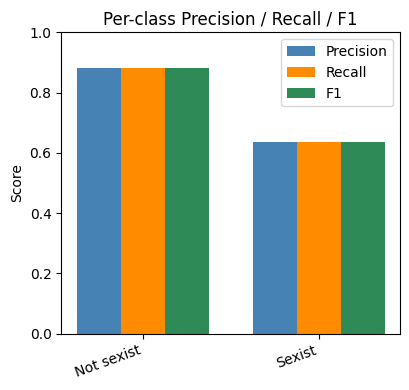


ERROR ANALYSIS

Total errors: 709 / 4000 (17.7%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,354,970,36.5
0,Not sexist,355,3030,11.7



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,355
1,Sexist,Not sexist,354


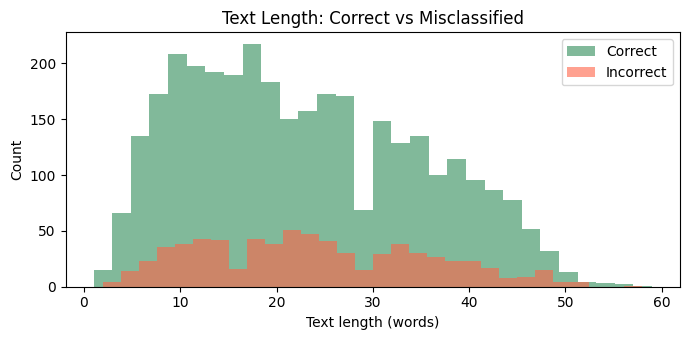


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 355)
    • (0.89) 'tis true as the puff and pass lead to the munchies and philosophy.
    • (0.96) i have some unwashed underwear she can sniff i am not sure if it is sarin but i am positive it is toxic and probably wmd
    • (0.98) you mean those videos where a woman slaps a guy when she's fucked up? we see those everyday already.

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 354)
    • (0.76) i would pay to see her ass cracker. #nsfw
    • (0.71) if you don't want your mother fucked, keep her off the streets
    • (0.80) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [2]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.4611     0.2057    0.2066    0.3485    0.3435    LR: 5.00e-04


2      1.3272     0.3916    0.3984    0.4144    0.4102    LR: 5.00e-04


3      1.2361     0.4923    0.5133    0.4794    0.4793    LR: 5.00e-04


4      1.1475     0.5801    0.6162    0.4876    0.4786    LR: 5.00e-04


...

9      0.8362     0.8975    0.9187    0.5278    0.4847    LR: 2.50e-04


10     0.8088     0.9258    0.9410    0.5247    0.4711    LR: 2.50e-04


11     0.7899     0.9488    0.9570    0.5237    0.4630    LR: 1.25e-04


12     0.7597     0.9681    0.9730    0.5299    0.4850    LR: 1.25e-04


13     0.7579     0.9730    0.9777    0.5216    0.4880    LR: 1.25e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.53      0.57      0.55        89
           Derogation       0.55      0.58      0.57       454
            Animosity       0.49      0.49      0.49       333
Prejudiced Discussion       0.43      0.29      0.34        94

             accuracy                           0.52       970
            macro avg       0.50      0.48      0.49       970
         weighted avg       0.52      0.52      0.52       970

Accuracy : 0.5216
Macro F1 : 0.4880
Weighted F1 : 0.5181

Confusion Matrix (raw):
[[ 51  24  11   3]
 [ 25 264 142  23]
 [  9 150 164  10]
 [ 12  40  15  27]]


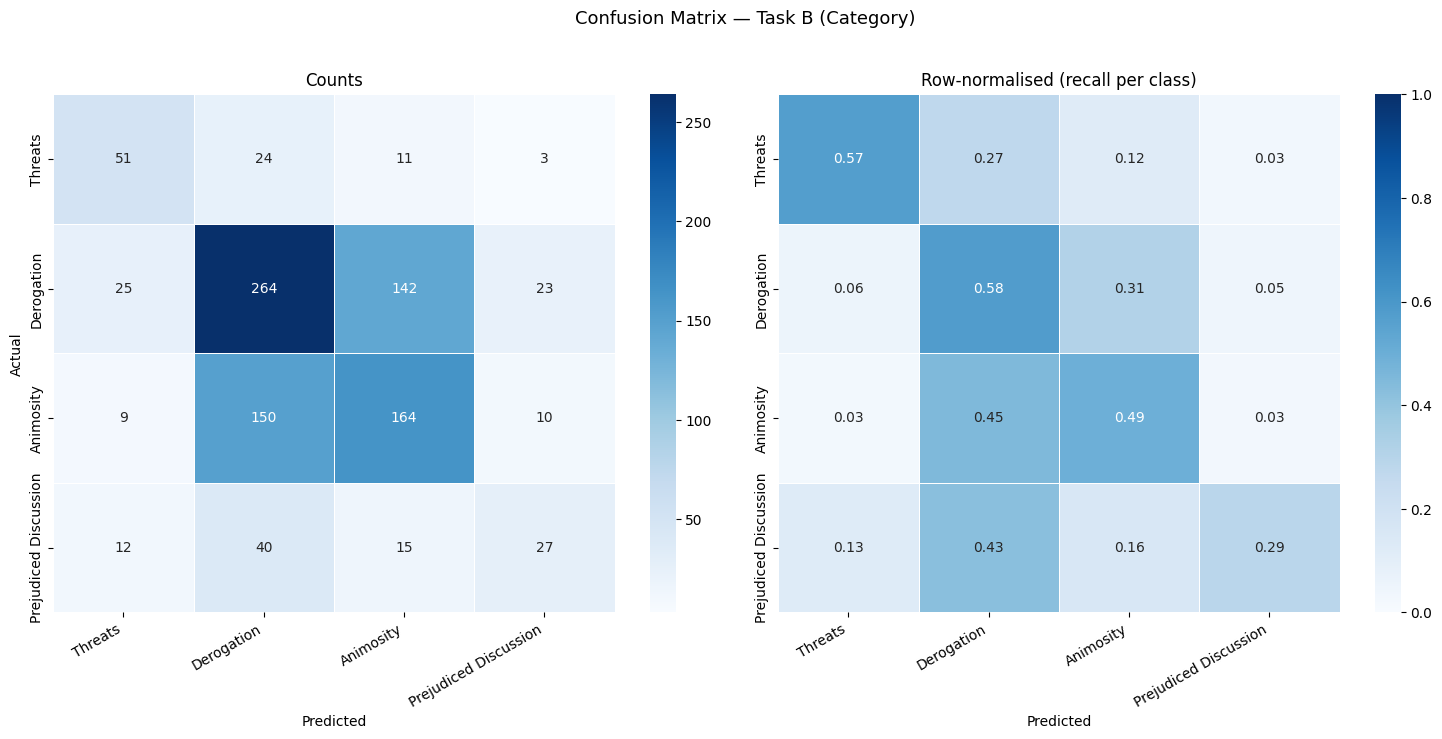

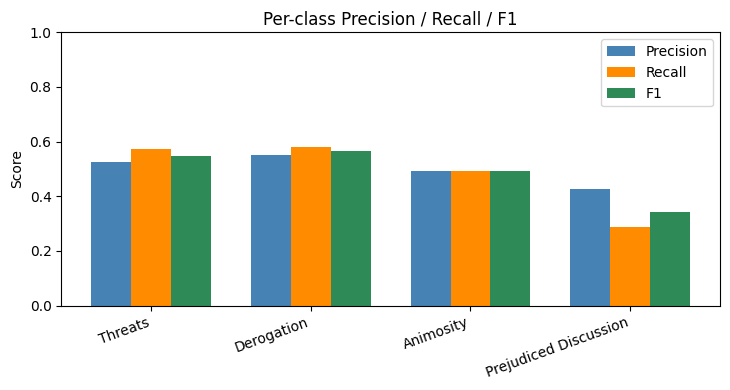


ERROR ANALYSIS

Total errors: 464 / 970 (47.8%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,67,94,71.3
2,Animosity,169,333,50.8
0,Threats,38,89,42.7
1,Derogation,190,454,41.9



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,150
3,Derogation,Animosity,142
7,Prejudiced Discussion,Derogation,40
5,Derogation,Threats,25
10,Threats,Derogation,24
4,Derogation,Prejudiced Discussion,23
6,Prejudiced Discussion,Animosity,15
8,Prejudiced Discussion,Threats,12
9,Threats,Animosity,11
1,Animosity,Prejudiced Discussion,10


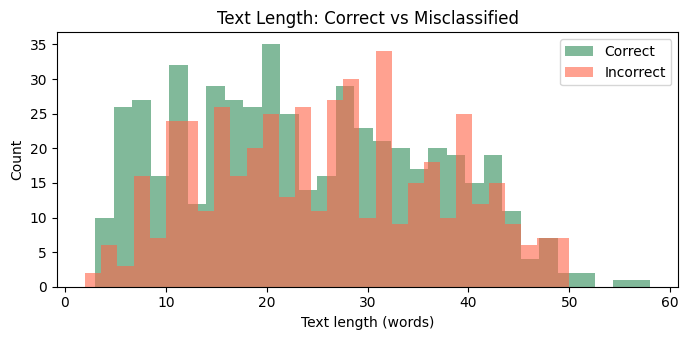


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 150)
    • (0.45) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (0.62) most here would fuck her.
    • (0.62) soy boys pms worse than women cause it's 24/7. they get their delicate feelings hurt because of lack of testosterone.it'

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 142)
    • (0.73) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.71) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (0.73) if you don't want your mother fucked, keep her off the streets

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 40)
    • (0.54) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l
    • (0.67) yes, it 

In [3]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

12     0.3956     0.9876    0.9830    0.8548    0.8155    LR: 1.00e-05


13     0.3875     0.9916    0.9886    0.8642    0.8165    LR: 9.44e-06


14     0.3863     0.9916    0.9885    0.8740    0.8267    LR: 8.89e-06


15     0.3830     0.9935    0.9912    0.8782    0.8262    LR: 8.33e-06


16     0.3812     0.9940    0.9918    0.8768    0.8282    LR: 7.78e-06

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.91      0.93      0.92      3030
      Sexist       0.76      0.71      0.74       970

    accuracy                           0.88      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.87      0.88      0.88      4000

Accuracy : 0.8768
Macro F1 : 0.8282
Weighted F1 : 0.8752

Confusion Matrix (raw):
[[2817  213]
 [ 280  690]]


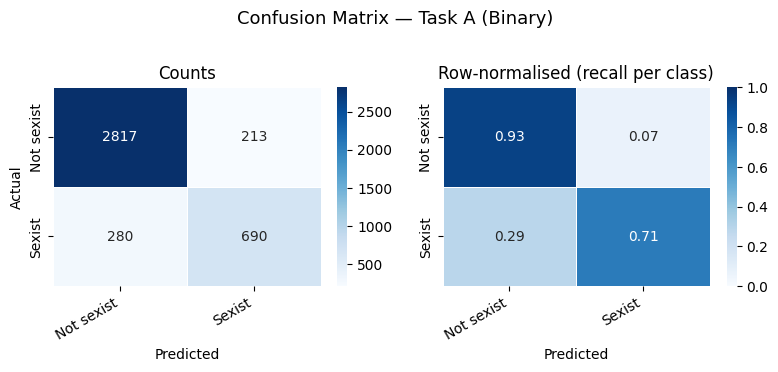

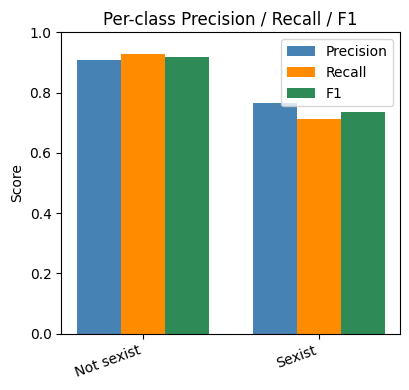


ERROR ANALYSIS

Total errors: 493 / 4000 (12.3%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,280,970,28.9
0,Not sexist,213,3030,7.0



Top confusion pairs (actual → predicted):


,actual,predicted,count
1,Sexist,Not sexist,280
0,Not sexist,Sexist,213


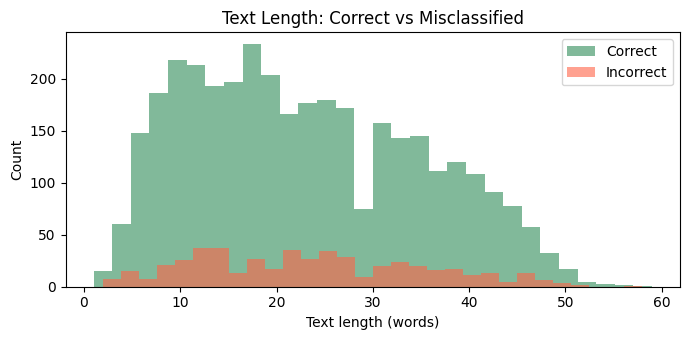


Sample misclassified examples:

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 280)
    • (0.80) i would pay to see her ass cracker. #nsfw
    • (0.80) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.80) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 213)
    • (0.96) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (0.98) the iron maiden, the toughest tranny in town.
    • (0.98) go get'chu sum white women's time to turn it around be a pimp before is too late!

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [4]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.5303     0.1738    0.1684    0.4113    0.3893    LR: 5.00e-06


...

13     0.7684     0.9833    0.9835    0.6330    0.6044    LR: 9.44e-06


14     0.7592     0.9864    0.9881    0.6093    0.5920    LR: 8.89e-06


15     0.7552     0.9892    0.9894    0.6196    0.6049    LR: 8.33e-06


16     0.7559     0.9900    0.9905    0.6144    0.6075    LR: 7.78e-06


17     0.7482     0.9915    0.9911    0.6082    0.5708    LR: 7.22e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.69      0.61      0.65        89
           Derogation       0.59      0.79      0.68       454
            Animosity       0.63      0.42      0.51       333
Prejudiced Discussion       0.57      0.37      0.45        94

             accuracy                           0.61       970
            macro avg       0.62      0.55      0.57       970
         weighted avg       0.61      0.61      0.59       970

Accuracy : 0.6082
Macro F1 : 0.5708
Weighted F1 : 0.5945

Confusion Matrix (raw):
[[ 54  25   6   4]
 [ 13 360  67  14]
 [  6 178 141   8]
 [  5  44  10  35]]


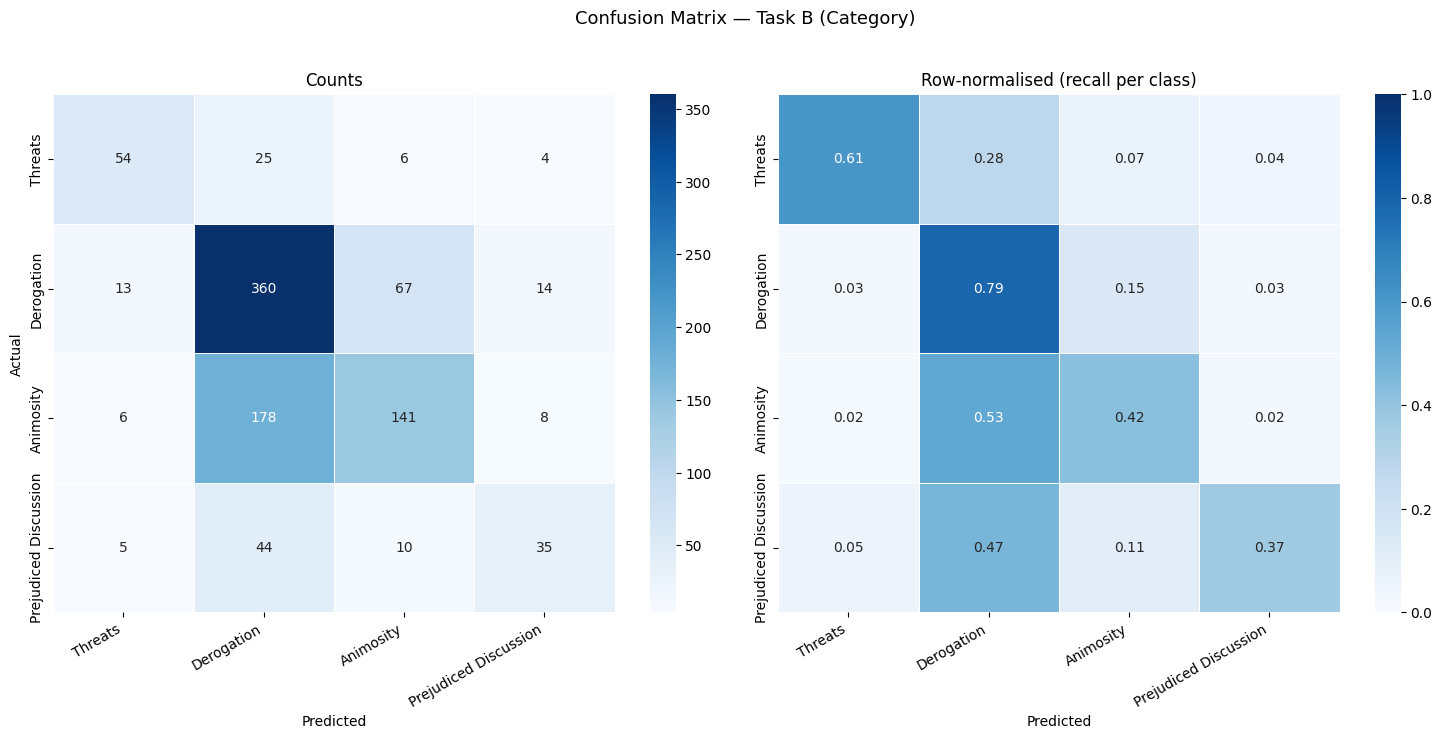

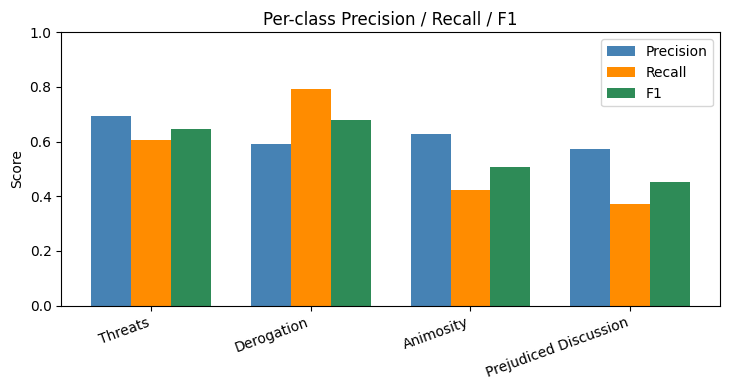


ERROR ANALYSIS

Total errors: 380 / 970 (39.2%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,59,94,62.8
2,Animosity,192,333,57.7
0,Threats,35,89,39.3
1,Derogation,94,454,20.7



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,178
3,Derogation,Animosity,67
7,Prejudiced Discussion,Derogation,44
10,Threats,Derogation,25
4,Derogation,Prejudiced Discussion,14
5,Derogation,Threats,13
6,Prejudiced Discussion,Animosity,10
1,Animosity,Prejudiced Discussion,8
2,Animosity,Threats,6
9,Threats,Animosity,6


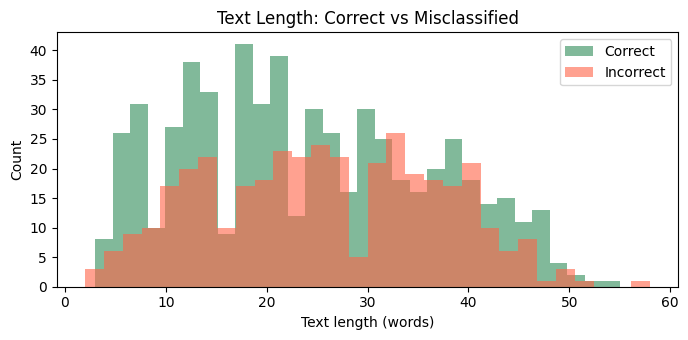


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 178)
    • (0.70) it's different since nobody (least of all feminazis like you) gives a flying fuck about sexual assault when it's men, bu
    • (0.70) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (0.70) most here would fuck her.

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 67)
    • (0.77) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.77) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (0.62) some, a very few men get a free and easy lay. if you are not sexually attractive, you don't get to be a horsie on the co

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 44)
    • (0.70) yes, it is new. what remains constant is that feminists are playing to the fears of w

In [5]:
tf_category = run_transformer_category(state, device)